# Машинное обучение, ФКН ВШЭ

# Практическое задание 13. Рекомендательные системы

## Общая информация
**Дата выдачи: 07.06.2024**

**Мягкий дедлайн: 23.06.2024 23:59 MSK**

**Жёсткий дедлайн: 23.06.2024 23:59 MSK**

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — **11** баллов + **2.5** бонусных.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-13-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

## О задании

В этой работе мы будем решать задачу рекомендации музыки. То есть мы поставим целью получить модель, которая для каждого пользователя будет возвращать набор треков, наиболее похожих на те, что он уже слушал. В первой части мы разберемся с memory-based подходом и моделью со скрытыми переменными. Это не очень мощные методы, но зато они позволяют строить предсказания почти моментально. Затем, во второй части, мы обратим внимание на то, что датасет содержит огромное число треков и воспользуемся результатами уже построенных быстрых моделей для сокращения списка кандидатов до разумного количества. После этого проведем ранжирование среди кандидатов с помощью сильной, но чуть более медленной модели, и отберем самые лучшие варианты. Такой двухэтапный алгоритм построения рекомендаций изображен на картинке.


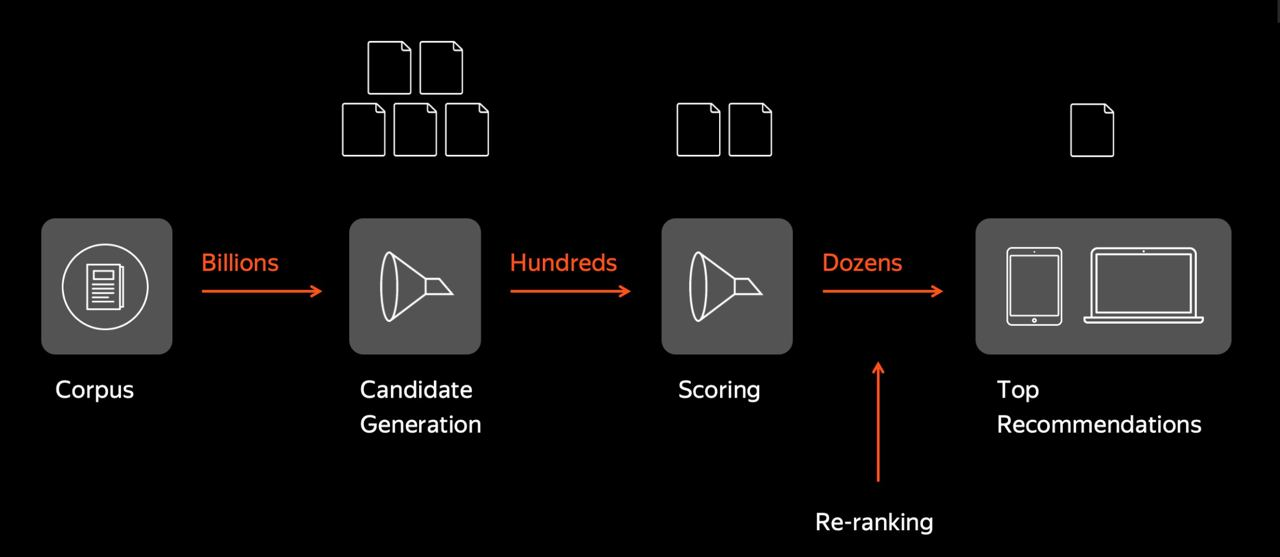

Приступим!

Все шаблоны ниже можно переписывать по своему усмотрению.

In [2]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs

In [3]:
ratings = pd.read_csv('music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [4]:
tracks_info = pd.read_csv('tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


Для оценки качества рекомендаций мы будем использовать метрику $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


*   $N$ - количество пользователей.
*   $n_u$ - число релевантных треков пользователя $u$ на тестовом промежутке.
*   $r_u(i)$ - бинарная величина: относится ли трек на позиции $i$ к релевантным.

**Задание 1 (0.5 балл).** Реализуйте метрику $MAP@k$.

In [5]:
def pk(relevant, predicted, k):
    return np.mean(np.isin(predicted[:k], relevant))

def apk(relevant, prediction, k):
    r = np.isin(prediction[:k], relevant)
    precisions = np.array([pk(relevant, prediction, i) for i in range(1, k + 1)])
    return np.sum(r * precisions) / min(k, len(relevant))

def mapk(relevants: List[List[int]], predicteds: List[List[int]], k: int = 20):
    return np.mean([apk(relevants[i], predicteds[i], k) for i in range(len(relevants))])

In [6]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

Разделим данные на тренировочные и тестовые так, чтобы в теcтовый датасет попали 50 последних треков каждого пользователя.

In [7]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    # getting train samples
    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings += [user_data[:-num_test_samples]]

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # getting train samples
    # we drop all tracks that are not presented it the training samples,
    # because we won't be able to learn representations for them
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [8]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Почистим табличку с информацией о треках и закодируем id треков так, чтобы они соответствовали их порядковому номеру.

In [9]:
tracks_info.head(4)

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']


In [10]:
train_ratings.head(2)

,userId,trackId
0,0,14
1,0,95


In [11]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [12]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [13]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

In [14]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [15]:
test_ratings.head()

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168


Соберем все релевантные треки для каждого пользователя в список.

In [16]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

**Задание 2 (0.5 балла).** Реализуйте метод `get_test_recommendations` в классе `BaseModel`. Он принимает на вход параметр `k` и возвращает массив из `k` наиболее подходящих треков для каждого пользователя. Не забывайте удалять уже прослушанные треки из рекомендуемых.

In [17]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.
        
    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []
        for user_id, _ in self.ratings.groupby('userId'):
            test_preds.append(self.recommend(user_id))
        
        test_preds = self.remove_train_items(test_preds, k)
        return test_preds[test_users]

### Часть 1. Коллаборативная фильтрация (User2User)

Идея: чтобы выбрать треки, которые понравятся пользователю, можно набрать несколько похожих на него пользователей (соседей) и посмотреть, какие треки они слушают. После этого остается агрегировать треки этих пользователей и выбрать самые популярные. Соответственно, задача состоит из двух частей: выбора функции похожести двух пользователей и способа агрегации.

В качестве функции похожести мы будем использовать меру Жаккара:

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$


Во всех формулах 
* $I_u$ - множество треков, прослушанных пользователем $u$.
* $r_{ui}$ - прослушал ли пользователь $u$ трек $i$ (0 или 1).

Множество соседей определим как $$N(u) = \{ v \in U \setminus \{u\} \mid s(u, v) > \alpha\},$$ где $\alpha \, - $ гиперпараметр.



Для агрегации мы будем пользоваться следующей формулой.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

**Задание 3.2 (0.5 балла).** Реализуйте функцию подсчета меры Жаккара.

Функция принимает матрицу оценок и вектор оценок пользователя $u$ и возвращает вектор со значениями похожести пользователя $u$ на всех пользователей. Старайтесь писать оптимизированный код, за неэффективную реализацию оценка может быть снижена.

In [18]:
def jaccard(ratings: np.array, user_vector: np.array) -> np.array:
    intersection = np.logical_and(ratings, user_vector).sum(axis=1)
    union = np.logical_or(ratings, user_vector).sum(axis=1)
    similarities = intersection / union
    return similarities

**Задание 4 (1 балл).** Реализуйте методы `similarity` и `recommend` класса `User2User`. `recommend` возвращает индексы треков, отсортированные в порядке убывания предсказанных оценок. Значение парамметра `alpha` можно менять по своему усмотрению так, чтобы оно было разумным.

In [19]:
class User2User(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)

        self.similarity_func = jaccard
        self.alpha = 0.01
        self.sims = None

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """
        return self.similarity_func(self.R, user_vector)

    def recommend(self, uid: int):
        self.sims = self.similarity(self.R[:, uid].reshape(-1, 1))
        neighbours = np.arange(self.n_users)[self.sims > self.alpha]
        neighbours = neighbours[neighbours != uid]
        
        if len(neighbours) == 0:
            return np.arange(self.n_items)[::-1]

        rs = np.sum(self.R[neighbours, :] * self.sims[neighbours].reshape(-1, 1), axis=0) # shape (n_items, )
        
        return np.arange(self.n_items)[np.argsort(rs)][::-1]

**Задание 5 (0.5 балл).** Постройте график зависимости значений $MAP@k$ от разных $k$ при рекомендации на основе меры Жаккара, сравните его с рекомендициями самых популярных треков и случайных. Какой из трех способов рекомендаций оказался лучшим?

In [20]:
ks = [1, 5, 10, 20, 50, 100]
u2u_model = User2User(train_ratings)
u2u_recs = u2u_model.get_test_recommendations(100)
random_recs = [np.random.choice(np.arange(u2u_model.n_items), 1000, replace=False) for i in range(len(test_relevant))]
mp_recs = [np.arange(u2u_model.n_items)[np.argsort(np.sum(u2u_model.R, axis=0))][-100:][::-1] for i in range(len(test_relevant))]

u2u_mapks = []
random_mapks = []
mp_mapks = []
for k in ks:
    u2u_mapks.append(mapk(relevants=test_relevant, predicteds=u2u_recs, k=k))
    random_mapks.append(mapk(relevants=test_relevant, predicteds=random_recs, k=k))
    mp_mapks.append(mapk(relevants=test_relevant, predicteds=mp_recs, k=k))

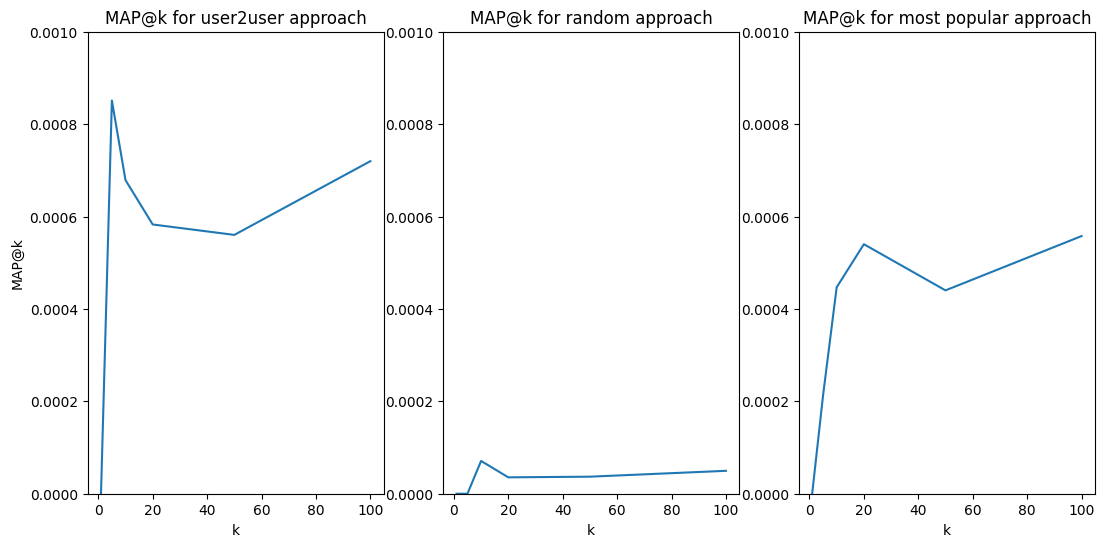

In [21]:
plt.figure(figsize=(13, 6)) 

plt.subplot(1, 3, 1)
plt.plot(ks, u2u_mapks)
plt.title('MAP@k for user2user approach')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.ylim(0, 0.001)


plt.subplot(1, 3, 2)
plt.plot(ks, random_mapks)
plt.title('MAP@k for random approach')
plt.xlabel('k')
plt.ylim(0, 0.001)


plt.subplot(1, 3, 3)
plt.plot(ks, mp_mapks)
plt.title('MAP@k for most popular approach')
plt.xlabel('k')
plt.ylim(0, 0.001)


plt.show()

In [22]:
print('best score for u2u: ')
print('k =', ks[np.argmax(u2u_mapks)])
print('score =', u2u_mapks[np.argmax(u2u_mapks)])
print('---------------------')
print('best score for random: ')
print('k =', ks[np.argmax(random_mapks)])
print('score =', random_mapks[np.argmax(random_mapks)])
print('---------------------')
print('best score for u2u: ')
print('k =', ks[np.argmax(mp_mapks)])
print('score =', mp_mapks[np.argmax(mp_mapks)])

best score for u2u: 
k = 5
score = 0.0008510638297872341
---------------------
best score for random: 
k = 10
score = 7.092198581560284e-05
---------------------
best score for u2u: 
k = 100
score = 0.0005576771776871034


In [23]:
print(u2u_mapks)

[0.0, 0.0008510638297872341, 0.0006788247213779128, 0.0005827918211819141, 0.0005602303446543147, 0.0007198274817515312]


**Бонус (1 балла).** Как вы могли заметить, матрица оценок получается очень разреженной, но мы работаем с ней как с обычной, это не дело. Перепишите код так, чтобы все методы могли работать с разреженными матрицами и сравните скорость работы такого подхода с оригинальным.

Мы можем посмотреть глазами, насколько хорошо модель рекомендует треки. Для этого сравним уже прослушанные треки с рекомендованными и релевантными для случайного пользователя. Хорошо ли у вас получилось?

In [21]:
user_id = np.random.randint(0, u2u_model.n_users)

In [22]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
10970,How Much Is The Fish?,['Scooter']
18870,Звёзды в лужах,['30.02']
23668,Дни Километры,['Nuteki']
24764,Roots,['Imagine Dragons']
26350,Смерть луны,['Asper X']
28622,"Детка, ты словно ламбо",['LUCAVEROS']
30578,Люби меня,"['Miyagi & Эндшпиль', 'Sимптом']"
30599,Санавабич,['Miyagi & Эндшпиль']
31292,Разрушительные сны,['Мимо Вселенной']
32668,It's Definitely You,"['V', 'Jin']"


In [23]:
preds = u2u_model.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

Predicted tracks:


,name,artists
56532,Балдёж,['Кузьма']
43777,Из-за тебя,['abdr.']
52213,Poezda (Mne Uzhe Ne Vazhno),"['RSAC', 'ELLA']"
35500,Капли вниз по бёдрам,['Скриптонит']
52212,Векторы,"['RSAC', 'ELLA']"
52211,ЭЙСИД,"['RSAC', 'ELLA']"
52210,Нет причин,"['RSAC', 'ELLA']"
52209,Оттенки,"['RSAC', 'ELLA']"
52208,Пустота внутри,"['RSAC', 'ELLA']"
52207,Ол инклюзив,"['RSAC', 'ELLA']"


In [24]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
65285,Мама я музыкант,['Nikitata']
65305,Опять пропаду,['Скаттл']
65339,Белая ночь,"['Lvnx', 'Алина Селях']"
65375,Не грусти,"['NLO', 'Dan Korshunov']"
65380,Leck,"['MORGENSHTERN', 'Imanbek', 'Fetty Wap', 'KDDK']"
65393,Touch It,['Dj Viral TikToker']
65424,Save Your Tears,"['The Weeknd', 'Ariana Grande']"
65461,Не лей,['Bakr']
65483,Федерико Феллини,['Galibri & Mavik']
65502,ПОСЛЕДНЕЕ ЛЕТО ДЕТСТВА,['Nikitata']


Вообще видно насколько разные первые 15 треков на трейне и на тесте. На трейне нет ни одного русского трека, а на тесте практически все русские. Сложно оценить насколько хорошо справилась наша модель, потому что в тесте реально довольно таки непопулярные треки, которые наша модель предсказать не смогла. Тем не менее в ответе нашей модели есть русские треки что уже радует. Кроме того у нашей модели уклон в сторону рекомендаций популярных треков, что не очень хорошо.

### Часть 2. Модель со скрытыми переменными: ALS

В этой части мы пощупаем метод рекомендаций со скрытыми переменными.
Идея: будем предсказывать оценки по формуле
$$
\hat{r}_{ui} = \langle p_u, q_u \rangle,
$$
$p_u \in \mathbb{R}^d$ и $q_i \in \mathbb{R}^d$ - латентные векторы пользователя $u$ и объекта $i$ соответственно. 

Оптимизировать мы будем MSE между истинной оценкой пользователя и предсказанной с регуляризацией
$$
L = \sum_{(u, i) \in R} (\hat{r}_{ui} - r_{ui})^2 + \lambda \left(\sum_{u \in U} \|p_u\|^2 + \sum_{i \in I} \|q_i\|^2\right)
$$

__P. S.__ Заметьте, что описанная модель предназначена для работы только с __явной__ информацией. В нашем случае от модели будет требоваться всегда возвращать 1, так как мы считаем ошибку только по парам, о которых получили фидбек. Поэтому логично подумать, что постановка задачи не имеет смысла. Однако, на практике оказывается, что из-за случайности в инициализации матриц $P$ и $Q$, обученные векторы для всех треков и пользователей в конце обучения получаются разными. Поэтому модель все же не лишена смысла.

__P. P. S.__ Для более разумной работы с неявной информацией был предложен метод iALS, его описание можно найти в лекции. Ниже будет бонус на его реализацию.

**Задание 6 (0.5 балла).** На лекции рассматривались два подхода к оптимизации параметров. Можно это делать обычным стохастческим градинтным спуском, а можно по очереди обновлять матрицы $P, Q$, и тогда получится метод Alternating Least Squares (ALS). Выведите формулы обновления параметров для обоих методов.

Ответ:

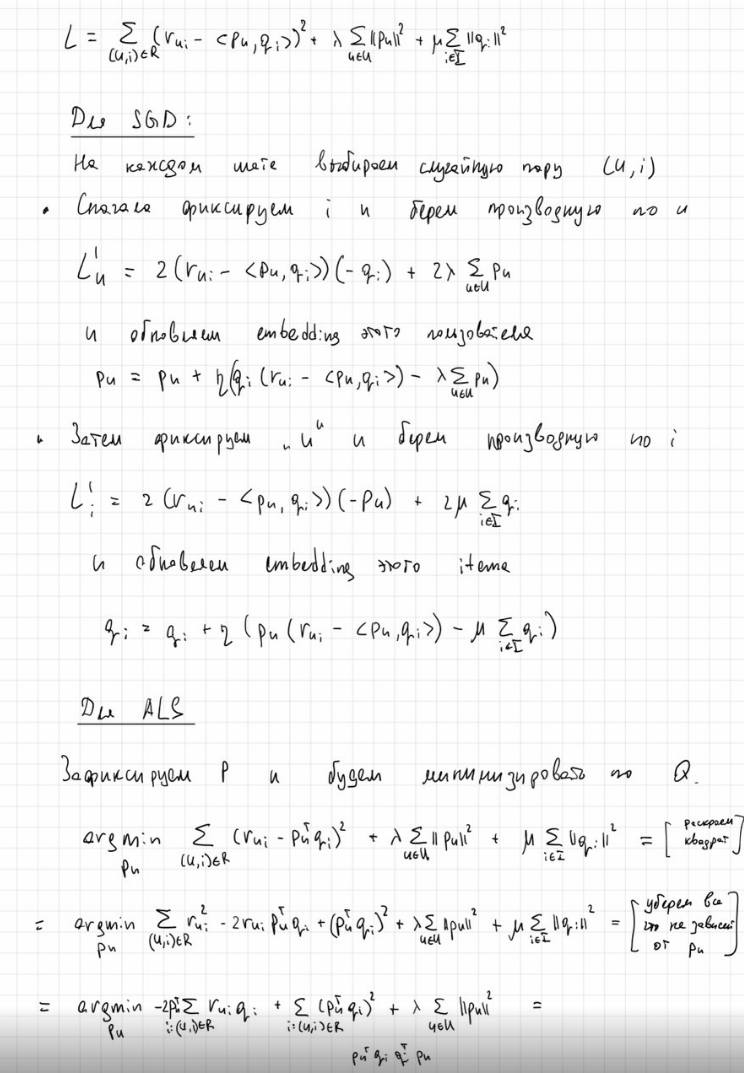

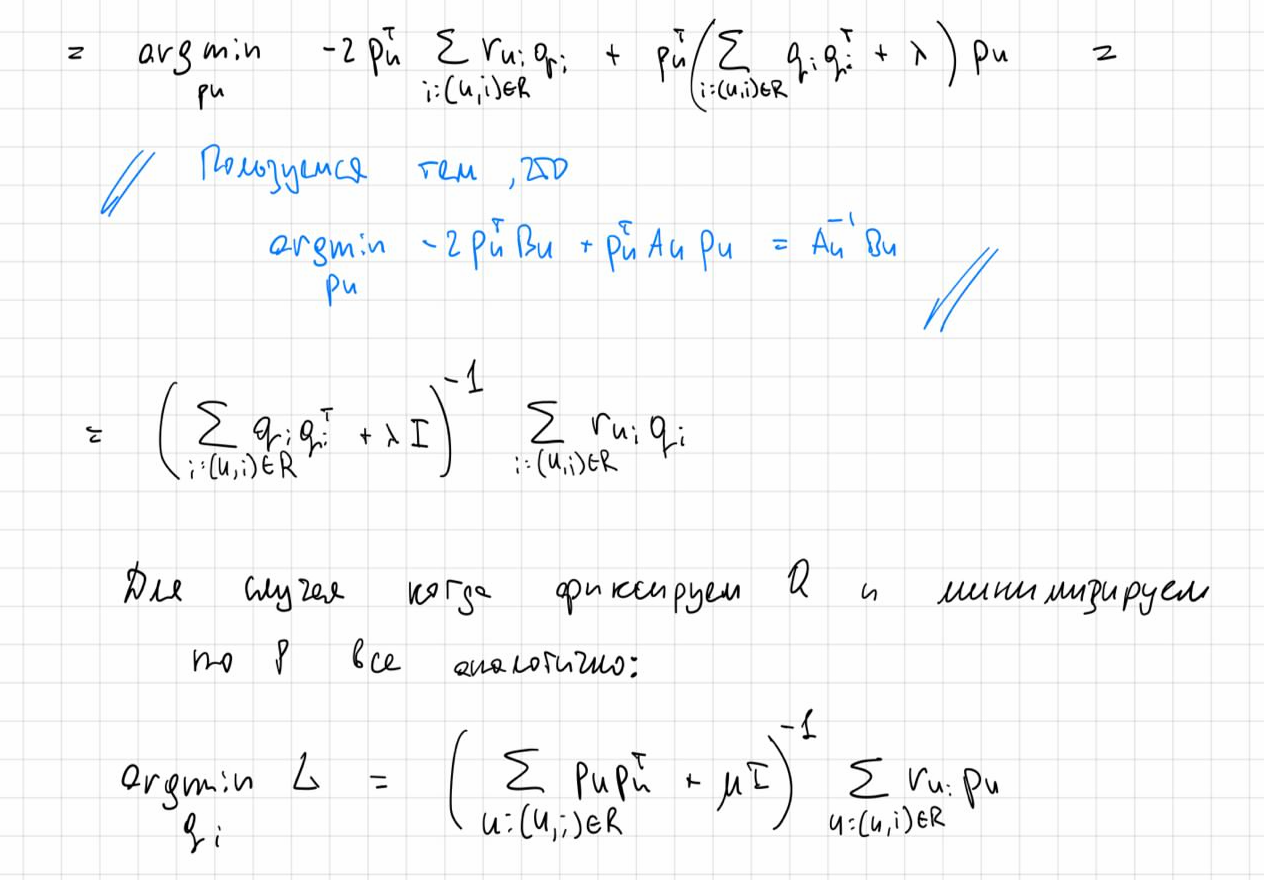



**Задание 7 (1.5 балла).** Реализуйте методы оптимизации параметров для обоих алгоритмов.

In [52]:
class LatentFactorModel(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd', lr=0.0003, lamb=0.01):
        super().__init__(ratings)
        self.dim = dim
        
        assert mode in ['sgd', 'als']
        self.mode = mode
        np.random.seed(42)
        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = lr
        self.lamb = lamb

    def fit(self, num_iters=5):
        for epoch in range(num_iters):

            if self.mode == 'sgd':
                u = np.random.randint(0, self.n_users)
                i = np.random.randint(0, self.n_items)

                self.P[u, :] += self.lr * (self.Q[i, :] * (self.R[u, i] - self.P[u, :].T @ self.Q[i, :]) - (self.lamb * self.P[u, :]))
                self.Q[i, :] += self.lr * (self.P[u, :] * (self.R[u, i] - self.P[u, :].T @ self.Q[i, :]) - (self.lamb * self.Q[i, :]))
                

            elif self.mode == 'als':
                u = np.random.randint(0, self.n_users)
                r = self.R[u, :].astype(int)
                q = self.Q[r, :]
                inv = np.linalg.inv(q.T @ q + self.lamb * np.eye(self.dim))
                self.P[u, :] = inv @ np.sum(q, axis=0)

                i = np.random.randint(0, self.n_items)
                r = self.R[:, i].astype(int)
                p = self.P[r, :]
                inv = np.linalg.inv(p.T @ p + self.lamb + np.eye(self.dim))
                self.Q[i, :] = inv @ np.sum(p, axis=0)

    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T

        return np.argsort(pred_rating)[::-1]

**Задание 8 (1 балл).** Для обоих алгоритмов подберите оптимальные значения размерности скрытого пространства $d$ и размера предсказания $k$. Как изменяется качество предсказаний с числом итераций обучения? Постройте соответствующие графики, сравните со случайным подхом и User2User, сделайте выводы. Какой алгоритм вам кажется более подходящим для данной задачи и почему?

__P. S.__ Хотя бы один из методов обучения должен приводить к лучшим результатам в сравнении с User2User подходом.

__P. P. S.__ Методу SGD свойственно переобучаться, поэтому при подборе параметров полезно смотреть на значения ошибки и оптимизируемой метрики на тренировочном датасете. Вы также можете менять начальную инициализацию и прочие параметры, за исключением архитектуры, на ваш вкус.

В метрике MAP@k использовал k=5 потому, что user2user подход показал наилучшее качество именно при таком k.

In [252]:
import optuna

def als_objective(trial):
    dim = trial.suggest_int('dim', 64, 200)
    k = trial.suggest_int('k', 1, 10)
    lamb = trial.suggest_float('lamb', 0.001, 0.1)

    model = LatentFactorModel(train_ratings, dim=dim, mode='als', lamb=lamb)
    model.fit(num_iters=10)
    lfm_recs = model.get_test_recommendations(k=k)
    
    return mapk(relevants=test_relevant, predicteds=lfm_recs, k=k)

def sgd_objective(trial):
    dim = trial.suggest_int('dim', 64, 200)
    k = trial.suggest_int('k', 10, 100)
    lr = trial.suggest_float('lr', 0.0001, 0.001)
    lamb = trial.suggest_float('lamb', 0.001, 0.1)

    model = LatentFactorModel(train_ratings, dim=dim, mode='sgd', lr=lr, lamb=lamb)
    model.fit(num_iters=5000)
    lfm_recs = model.get_test_recommendations(k=k)
    
    return mapk(relevants=test_relevant, predicteds=lfm_recs, k=k)

In [253]:
als_study = optuna.create_study(direction='maximize')
als_study.optimize(als_objective, n_trials=20)

print('Best hyperparameters for als: ', als_study.best_params)

[I 2024-06-12 15:56:45,674] A new study created in memory with name: no-name-40c3adb3-ca0e-48d8-afd4-bd44dec8bc93
[I 2024-06-12 15:56:54,306] Trial 0 finished with value: 0.0 and parameters: {'dim': 200, 'k': 6, 'lamb': 0.046679914255618044}. Best is trial 0 with value: 0.0.
[I 2024-06-12 15:57:02,015] Trial 1 finished with value: 0.0 and parameters: {'dim': 161, 'k': 9, 'lamb': 0.003972844062039625}. Best is trial 0 with value: 0.0.
[I 2024-06-12 15:57:06,010] Trial 2 finished with value: 0.00026595744680851064 and parameters: {'dim': 72, 'k': 4, 'lamb': 0.07615640769165818}. Best is trial 2 with value: 0.00026595744680851064.
[I 2024-06-12 15:57:12,451] Trial 3 finished with value: 0.0 and parameters: {'dim': 152, 'k': 8, 'lamb': 0.06582740282090822}. Best is trial 2 with value: 0.00026595744680851064.
[I 2024-06-12 15:57:20,477] Trial 4 finished with value: 6.648936170212766e-05 and parameters: {'dim': 187, 'k': 8, 'lamb': 0.07998609083020092}. Best is trial 2 with value: 0.00026595

Best hyperparameters for als:  {'dim': 103, 'k': 1, 'lamb': 0.05032080981963853}


In [254]:
sgd_study = optuna.create_study(direction='maximize')
sgd_study.optimize(sgd_objective, n_trials=20)

print('Best hyperparameters for als: ', sgd_study.best_params)

[I 2024-06-12 15:59:07,309] A new study created in memory with name: no-name-63ed0c80-f4b2-4267-8708-5d6f85854286
[I 2024-06-12 15:59:14,173] Trial 0 finished with value: 4.455823199516382e-05 and parameters: {'dim': 154, 'k': 81, 'lr': 0.0006074082852532692, 'lamb': 0.019059756760993873}. Best is trial 0 with value: 4.455823199516382e-05.
[I 2024-06-12 15:59:22,032] Trial 1 finished with value: 1.9523700369595838e-05 and parameters: {'dim': 172, 'k': 91, 'lr': 0.0001357792484634528, 'lamb': 0.032664562237389005}. Best is trial 0 with value: 4.455823199516382e-05.
[I 2024-06-12 15:59:28,439] Trial 2 finished with value: 0.00012526317460186625 and parameters: {'dim': 132, 'k': 73, 'lr': 0.000702641765133153, 'lamb': 0.02648984723651792}. Best is trial 2 with value: 0.00012526317460186625.
[I 2024-06-12 15:59:34,737] Trial 3 finished with value: 4.675995803501373e-05 and parameters: {'dim': 200, 'k': 40, 'lr': 0.0005198467384563407, 'lamb': 0.09215394853901857}. Best is trial 2 with valu

Best hyperparameters for als:  {'dim': 197, 'k': 52, 'lr': 0.00037023633928426976, 'lamb': 0.0015067034261996917}


In [255]:
sgd_bp = sgd_study.best_params
als_bp = als_study.best_params

lfm_model = LatentFactorModel(train_ratings, mode='sgd', dim=sgd_bp['dim'], lr=sgd_bp['lr'], lamb=sgd_bp['lamb'])
lfm_model.fit(5000)
lfm_recs = lfm_model.get_test_recommendations(sgd_bp['k'])
print('best SGD result: ', mapk(relevants=test_relevant, predicteds=lfm_recs, k=sgd_bp['k']))

lfm_model = LatentFactorModel(train_ratings, mode='als', dim=als_bp['dim'], lamb=als_bp['lamb'])
lfm_model.fit(10)
lfm_recs = lfm_model.get_test_recommendations(als_bp['k'])
print('best ALS result: ', mapk(relevants=test_relevant, predicteds=lfm_recs, k=als_bp['k']))


best SGD result:  0.00017760378210941413
best ALS result:  0.00425531914893617


Ура, удалось побить результат user2user подхода. Там было 0.000851.

In [256]:
sgd_max_iters = [10, 20, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
als_max_iters = [10, 20, 200, 500, 1000]

lfm_sgd_scores = []
lfm_als_scores = []
for max_iter in sgd_max_iters:
    lfm_model = LatentFactorModel(train_ratings, mode='sgd', dim=sgd_bp['dim'], lr=sgd_bp['lr'], lamb=sgd_bp['lamb'])
    lfm_model.fit(max_iter)
    lfm_recs = lfm_model.get_test_recommendations(sgd_bp['k'])
    lfm_sgd_scores.append(mapk(relevants=test_relevant, predicteds=lfm_recs, k=5))

for max_iter in als_max_iters:
    lfm_model = LatentFactorModel(train_ratings, mode='als', dim=als_bp['dim'], lamb=als_bp['lamb'])
    lfm_model.fit(max_iter)
    lfm_recs = lfm_model.get_test_recommendations(als_bp['k'])
    lfm_als_scores.append(mapk(relevants=test_relevant, predicteds=lfm_recs, k=5))

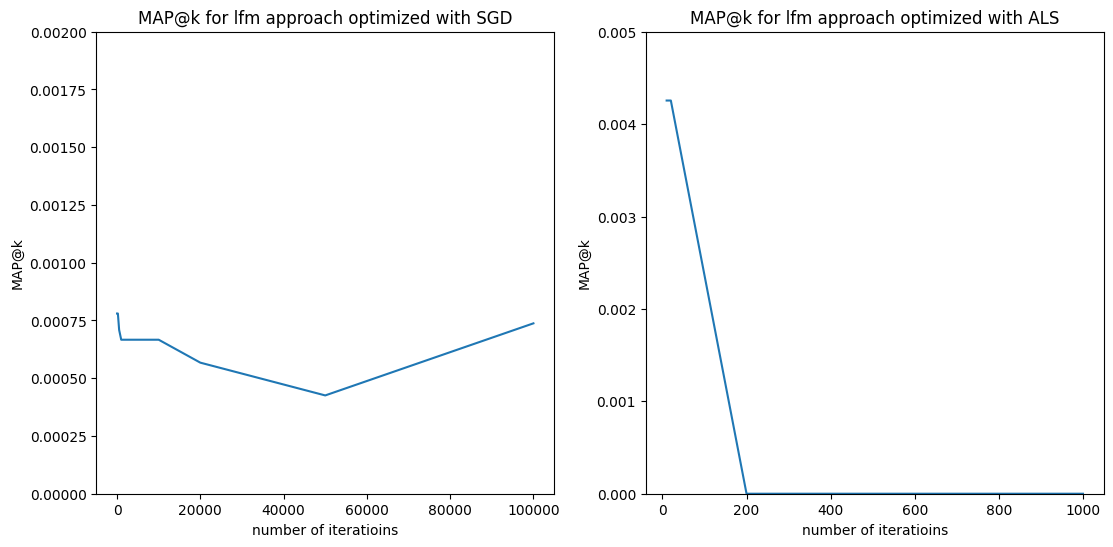

In [273]:
plt.figure(figsize=(13, 6)) 

plt.subplot(1, 2, 1)
plt.plot(sgd_max_iters, lfm_sgd_scores)
plt.title('MAP@k for lfm approach optimized with SGD')
plt.xlabel('number of iteratioins')
plt.ylabel('MAP@k')
plt.ylim(0, 0.002)

plt.subplot(1, 2, 2)
plt.plot(als_max_iters, lfm_als_scores)
plt.title('MAP@k for lfm approach optimized with ALS')
plt.xlabel('number of iteratioins')
plt.ylabel('MAP@k')
plt.ylim(0, 0.005)


plt.show()

Видим, что als довольно сильно переобучается. При увеличении итераций качество падает как в первом, так и во втором случаях.

In [293]:
lfm_model = LatentFactorModel(train_ratings, mode='als', dim=als_bp['dim'], lamb=als_bp['lamb'])
lfm_model.fit(10)
lfm_recs = lfm_model.get_test_recommendations(als_bp['k'])
mapk(relevants=test_relevant, predicteds=lfm_recs, k=20)

0.00425531914893617

Если у вас получилось достаточно хорошее качество, то при оптимизации параметров марицы $Q$ похожим трекам стали соответствовать похожие векторы. Поэтому мы можем для любого трека найти наиболее близкие к нему в латентном пространстве и проверить степерь обученности модели вручную.

In [275]:
example_trackId = tracks_info[tracks_info.name == 'Выхода нет'].iloc[0].id

preds = lfm_model.Q @ lfm_model.Q[example_trackId]
preds = preds / np.sqrt((lfm_model.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

In [276]:
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(lfm_model.Q[example_trackId])
similar_tracks

,name,artists,similarity
5512,Выхода нет,['Сплин'],1.000000
30385,Пятилетка,['Марлины'],0.434001
67067,Улыбайся,"['Оля Краснова', 'IOWA']",0.425496
15726,Sadist,['Stone Sour'],0.402377
25868,C'est pas moi,['Mylène Farmer'],0.392702
50164,Я схожу с ума,['Burito'],0.382096
34243,Get Ur Freak On,['Missy Elliott'],0.376832
32884,Thunder,"['Marcus Miller', 'Victor Wooten', 'Stanley Cl...",0.360096
8614,Lost Without You,['Beverley Craven'],0.357354
12315,Легион,['Агата Кристи'],0.350489


не суперкруто конечно, но хотя бы зверей нашел.

**Бонус (1.5 балла).**

Постройте модель iALS и сравните ее качество с обучением ALS и SGD.

Будем пользоваться формулами из яндекс [учебника](https://education.yandex.ru/handbook/ml/article/rekomendacii-na-osnove-matrichnyh-razlozhenij). Добавим к уже имеющимся методам оптимизации в классе LatentFactorModel метод ials.

Итоговые формулы выглядят так:

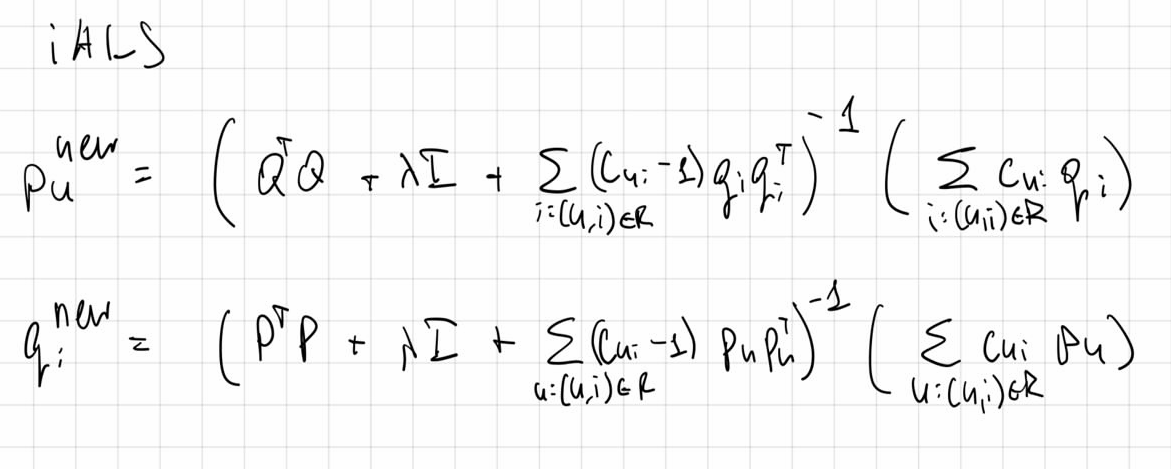

тут для простоты реализации возьмем $c_{ui} = 2$

In [102]:
class LatentFactorModel(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd', lr=0.0003, lamb=0.01):
        super().__init__(ratings)
        self.dim = dim
        
        assert mode in ['sgd', 'als', 'ials']
        self.mode = mode
        np.random.seed(42)
        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = lr
        self.lamb = lamb

    def fit(self, num_iters=5):
        qtq = None
        ptp = None
        
        if self.mode == 'ials':
            qtq = self.Q.T @ self.Q
            ptp = self.P.T @ self.P
        
        for epoch in range(num_iters):

            if self.mode == 'sgd':
                u = np.random.randint(0, self.n_users)
                i = np.random.randint(0, self.n_items)

                self.P[u, :] += self.lr * (self.Q[i, :] * (self.R[u, i] - self.P[u, :].T @ self.Q[i, :]) - (self.lamb * self.P[u, :]))
                self.Q[i, :] += self.lr * (self.P[u, :] * (self.R[u, i] - self.P[u, :].T @ self.Q[i, :]) - (self.lamb * self.Q[i, :]))
                

            elif self.mode == 'als':
                u = np.random.randint(0, self.n_users)
                r = self.R[u, :].astype(int)
                q = self.Q[r, :]
                inv = np.linalg.inv(q.T @ q + self.lamb * np.eye(self.dim))
                self.P[u, :] = inv @ np.sum(q, axis=0)

                i = np.random.randint(0, self.n_items)
                r = self.R[:, i].astype(int)
                p = self.P[r, :]
                inv = np.linalg.inv(p.T @ p + self.lamb + np.eye(self.dim))
                self.Q[i, :] = inv @ np.sum(p, axis=0)

            elif self.mode == 'ials':
                u = np.random.randint(0, self.n_users)
                r = self.R[u, :].astype(int)
                q = self.Q[r, :]
                inv = np.linalg.inv(q.T @ q + self.lamb * np.eye(self.dim) + qtq)
                self.P[u, :] = inv @ np.sum(q, axis=0) * 2

                i = np.random.randint(0, self.n_items)
                r = self.R[:, i].astype(int)
                p = self.P[r, :]
                inv = np.linalg.inv(p.T @ p + self.lamb + np.eye(self.dim) + ptp)
                self.Q[i, :] = inv @ np.sum(p, axis=0) * 2


    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T

        return np.argsort(pred_rating)[::-1]

In [109]:
def ials_objective(trial):
    dim = trial.suggest_int('dim', 64, 200)
    k = trial.suggest_int('k', 10, 100)
    lamb = trial.suggest_float('lamb', 0.001, 0.1)

    model = LatentFactorModel(train_ratings, dim=dim, mode='ials', lamb=lamb)
    model.fit(num_iters=100)
    lfm_recs = model.get_test_recommendations(k=k)
    
    return mapk(relevants=test_relevant, predicteds=lfm_recs, k=5)

In [110]:
ials_study = optuna.create_study(direction='maximize')
ials_study.optimize(ials_objective, n_trials=20)

print('Best hyperparameters for ials: ', ials_study.best_params)

[I 2024-06-12 11:19:42,120] A new study created in memory with name: no-name-f2ced515-4076-4f28-a07e-8a302f3874c8
[I 2024-06-12 11:19:57,513] Trial 0 finished with value: 0.00021276595744680854 and parameters: {'dim': 82, 'k': 38, 'lamb': 0.01172247450113047}. Best is trial 0 with value: 0.00021276595744680854.
[I 2024-06-12 11:20:20,947] Trial 1 finished with value: 0.0 and parameters: {'dim': 153, 'k': 60, 'lamb': 0.025842594051466456}. Best is trial 0 with value: 0.00021276595744680854.
[I 2024-06-12 11:20:48,931] Trial 2 finished with value: 0.0 and parameters: {'dim': 181, 'k': 86, 'lamb': 0.01727237020353307}. Best is trial 0 with value: 0.00021276595744680854.
[I 2024-06-12 11:21:09,131] Trial 3 finished with value: 0.0 and parameters: {'dim': 111, 'k': 26, 'lamb': 0.05524711794528587}. Best is trial 0 with value: 0.00021276595744680854.
[I 2024-06-12 11:21:30,575] Trial 4 finished with value: 0.0 and parameters: {'dim': 99, 'k': 73, 'lamb': 0.03187308133204208}. Best is trial 0

Best hyperparameters for ials:  {'dim': 95, 'k': 46, 'lamb': 0.06809931591145103}


In [103]:
ials_bp = ials_study.best_params
lfm_model = LatentFactorModel(train_ratings, mode='ials', dim=ials_bp['dim'], lamb=ials_bp['lamb'])
lfm_model.fit(100)
lfm_recs = lfm_model.get_test_recommendations(ials_bp['k'])
mapk(relevants=test_relevant, predicteds=lfm_recs, k=5)

0.00021276595744680854

Что-то обычный als показал себя получше.

### Часть 3. Второй уровень рекомендаций.

Выше мы построили простейшие модели, которые показывают не слишком высокое качество, но зато работают очень быстро. Воспользуемся ими для того, чтобы отобрать некоторое количество наиболее перспективных треков, которые мы сможем отранжировать уже более сложной моделью (в нашем случае это будет [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboost)).

**Задание 9 (1 балл).**

Для каждого пользователя возьмите топ-100 рекомендованных треков от модели LFM (ALS или SGD на ваш выбор) и топ-100 от модели User2User. Это будут наши кандидаты, которые мы затем будем ранжировать бустингом.

In [279]:
lfm_model = LatentFactorModel(train_ratings, mode='als', dim=als_bp['dim'], lamb=als_bp['lamb'])
lfm_model.fit(11)
lfm_recs = lfm_model.get_test_recommendations(100)
u2u_recs = u2u_model.get_test_recommendations(100)

In [280]:
lfm_recs.shape, u2u_recs.shape

((235, 100), (235, 100))

In [281]:
recs = np.concatenate((lfm_recs, u2u_recs), axis=1)

In [282]:
recs.shape

(235, 200)

**Задание 10 (2 балла).**

Подготовьте датасет для обучения модели ранжирования. Он должен состоять из пар: объект, целевая переменная. Объект - это пара (user, item) и всякие дополнительные признаки на их основе. Предлагается создать набор следущих признаков, однако вы можете добавлять свои по желанию, если они вам кажутся разумными:
 1) id пользователя
 1) id трека
 1) косинусное расстояние между эмбеддингами LFM соответствующих пользователя и трека
 1) среднее значение меры Жаккара между этим пользователем и остальными из User2User модели
 1) доля пользователей, слушавших этот трек (взять из обучающей выборки в Части 1)
 1) количество прослушанных пользователем треков (взять из обучающей выборки в Части 1)

В качестве целевой переменной возьмем бинарную метку "попал ли трек в 50 последних прослушанных пользователем"

Разбейте полученную выборку на обучающую и тестовую в отношении 3:2 так, чтобы пропорции положительных и отрицательных примеров в обоих подвыборках были одинаковыми.

In [290]:
columns = [
    "user_id",
    "track_id",
    "cosine_distance",
    "avg_jaccard_user2user",
    "track_listen_ratio",
    "user_track_count",
    "in_last_50"
]
df = pd.DataFrame(columns=columns)

n_users, n_recs = u2u_recs.shape
for i in range(len(test_users)):
    user_id = test_users[i]
    for track_id in list(set(recs[i])):
        cosdist = lfm_model.P[user_id, :].T @ lfm_model.Q[track_id, :]
        avg_jaccard_user2user = np.mean(u2u_model.sims)
        track_listen_ratio = np.mean(lfm_model.R[:, track_id])
        user_track_count = np.sum(lfm_model.R[user_id, :])
        new_data = {
            "user_id": user_id,
            "track_id": track_id,
            "cosine_distance": cosdist,
            "avg_jaccard_user2user": avg_jaccard_user2user,
            "track_listen_ratio": track_listen_ratio,
            "user_track_count": user_track_count,
            "in_last_50": int(track_id in test_relevant[i])
        }
        df.loc[len(df)] = new_data

In [291]:
df.head(3)

,user_id,track_id,cosine_distance,avg_jaccard_user2user,track_listen_ratio,user_track_count,in_last_50
0,0,45569,28.051262,0.000008,0.004149,206.0,0
1,0,67304,12.184917,0.000008,0.004149,206.0,0
2,0,51208,31.411927,0.000008,0.004149,206.0,0


In [292]:
df['in_last_50'].sum()

38

In [265]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=2/5, random_state=42, stratify=y)

In [266]:
train = train.sort_values(by='user_id')
X_train = train.drop('in_last_50', axis=1)
y_train = train['in_last_50']

test = test.sort_values(by='user_id')
X_test = test.drop('in_last_50', axis=1)
y_test = test['in_last_50']

Как уже было сказано, для построения ранжирующей модели мы будем пользоваться библиотекой [CatBoost](https://www.youtube.com/watch?v=dQw4w9WgXcQ). 

Для преобразования датасета в удобный вид полезно использовать метод [`Pool`](https://catboost.ai/en/docs/concepts/python-reference_pool).

In [267]:
import catboost

# group_id == user_id here
train_pool = catboost.Pool(X_train, y_train, group_id=X_train['user_id'])
test_pool = catboost.Pool(X_test, y_test, group_id=X_test['user_id'])

**Задание 11 (1 балл)**

Обучите `CatBoostClassifier`. С его помощью сделайте предсказания для тестовой выборки и посчитайте MAP@20. Сравните с рекомендациями моделей User2User и LFM. Учтите, что для честного сравнения необходимо пересчитать предсказания моделей на нашей новой тестовой выборке. Получилось ли улучшить результаты?

In [268]:
from catboost import CatBoostClassifier
from catboost import CatBoostRanker

In [269]:
model = CatBoostClassifier()
model.fit(train_pool, silent=True)
probs = model.predict_proba(test_pool)

In [270]:
probs_df = pd.DataFrame({"user_id": X_test["user_id"], "track_id": X_test["track_id"], "p": -probs[:, 1]}).sort_values(by=["user_id", "p"])
probs_df["p"] = -probs_df["p"]

track_ids = probs_df.groupby("user_id").head(20).track_id
test_preds = track_ids.to_numpy().reshape(n_users, 20)

mapk(test_relevant, test_preds, k=20)

0.0018363285650519693

Как-то не очень - als справился лучше.

**Задание 12 (1 балл)**

Обучите `CatBoostRanker`, выбрав подходящую функцию ранжирования из тех, которые были рассмотрены на лекции. Проделайте все те же действия, что и с `CatBoostClassifier` и сравните результаты.

In [294]:
cb_ranker = CatBoostRanker(eval_metric="NDCG", verbose=False)
cb_ranker.fit(train_pool, eval_set=test_pool)
probs = cb_ranker.predict(test_pool)

In [295]:
probs_df = pd.DataFrame({"user_id": X_test["user_id"], "track_id": X_test["track_id"], "p": -probs}).sort_values(by=["user_id", "p"])
probs_df["p"] = -probs_df["p"]

track_ids = probs_df.groupby("user_id").head(20).track_id
test_preds = track_ids.to_numpy().reshape(n_users, 20)

mapk(test_relevant, test_preds, k=20)

0.002432557799299121

Тут уже получше, но у als все же было побольше. Думаю проблема в том, что предыдущие алгоритмы нашли слишком мало песен из топ50 из-за чего у катбуста недостаточно хорошие данные и он не может достичь лучшего качества.